# Задача 3: Параметрический резонанс

**Условие:**
Докажите, что при точном параметрическом резонансе амплитуда растет со временем экспоненциально.

**Доказательство:**

Рассмотрим уравнение Матье, описывающее параметрические колебания:
$$ \ddot{x} + \omega_0^2 (1 + h \cos(\gamma t)) x = 0 $$
где $h \ll 1$ — глубина модуляции.

Точный параметрический резонанс (главный) наступает при частоте накачки $\gamma = 2\omega_0$.
Уравнение принимает вид:
$$ \ddot{x} + \omega_0^2 (1 + h \cos(2\omega_0 t)) x = 0 $$

Будем искать решение в виде модулированных колебаний с медленно меняющимися амплитудами (метод Ван дер Поля):
$$ x(t) = a(t) \cos(\omega_0 t) + b(t) \sin(\omega_0 t) $$
где $a(t)$ и $b(t)$ — медленные функции времени ($\dot{a} \ll \omega_0 a$, $\ddot{a} \approx 0$).

Найдем производные:
$$ \dot{x} \approx -\omega_0 a \sin(\omega_0 t) + \omega_0 b \cos(\omega_0 t) + (\dot{a} \cos(\omega_0 t) + \dot{b} \sin(\omega_0 t)) $$
$$ \ddot{x} \approx -\omega_0^2 x + 2\omega_0 (\dot{b} \cos(\omega_0 t) - \dot{a} \sin(\omega_0 t)) $$
(членами с $\ddot{a}, \ddot{b}$ пренебрегаем).

Подставим в исходное уравнение:
$$ -\omega_0^2 x + 2\omega_0 (\dot{b} \cos - \dot{a} \sin) + \omega_0^2 x + \omega_0^2 h \cos(2\omega_0 t) (a \cos + b \sin) = 0 $$
$$ 2\omega_0 (\dot{b} \cos(\omega_0 t) - \dot{a} \sin(\omega_0 t)) + \omega_0^2 h [a \cos(2\omega_0 t)\cos(\omega_0 t) + b \cos(2\omega_0 t)\sin(\omega_0 t)] = 0 $$

Используем тригонометрические тождества:
$$ \cos(2\omega t)\cos(\omega t) = \frac{1}{2}(\cos(3\omega t) + \cos(\omega t)) $$
$$ \cos(2\omega t)\sin(\omega t) = \frac{1}{2}(\sin(3\omega t) - \sin(\omega t)) $$

Оставляем только резонансные члены (частота $\omega_0$), отбрасывая быстрые осцилляции $3\omega_0$ (метод усреднения):
$$ 2\omega_0 \dot{b} \cos(\omega_0 t) - 2\omega_0 \dot{a} \sin(\omega_0 t) + \frac{1}{2}\omega_0^2 h a \cos(\omega_0 t) - \frac{1}{2}\omega_0^2 h b \sin(\omega_0 t) = 0 $$

Приравниваем коэффициенты при $\cos(\omega_0 t)$ и $\sin(\omega_0 t)$ к нулю по отдельности:
1. При $\cos(\omega_0 t)$: $2\omega_0 \dot{b} + \frac{1}{2}\omega_0^2 h a = 0 \implies \dot{b} = -\frac{\omega_0 h}{4} a$
2. При $\sin(\omega_0 t)$: $-2\omega_0 \dot{a} - \frac{1}{2}\omega_0^2 h b = 0 \implies \dot{a} = -\frac{\omega_0 h}{4} b$

Получили систему линейных дифференциальных уравнений:
$$ \begin{cases} \dot{a} = -k b \\ \dot{b} = -k a \end{cases}, \quad \text{где } k = \frac{\omega_0 h}{4} $$

Продифференцируем первое уравнение: $\ddot{a} = -k \dot{b} = -k (-k a) = k^2 a$.
Решение для $a(t)$:
$$ a(t) = C_1 e^{kt} + C_2 e^{-kt} $$
Аналогично для $b(t)$.

Общее решение содержит растущую экспоненту $e^{kt} = \exp\left(\frac{\omega_0 h}{4} t\right)$.
Таким образом, амплитуда колебаний $A(t) = \sqrt{a^2+b^2}$ растет экспоненциально со временем. Инкремент нарастания равен $s = \frac{\omega_0 h}{4}$.

**Ч.Т.Д.**

<>:50: SyntaxWarning: invalid escape sequence '\s'
<>:53: SyntaxWarning: invalid escape sequence '\g'
<>:69: SyntaxWarning: invalid escape sequence '\s'
<>:50: SyntaxWarning: invalid escape sequence '\s'
<>:53: SyntaxWarning: invalid escape sequence '\g'
<>:69: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_5187/3671693240.py:50: SyntaxWarning: invalid escape sequence '\s'
  plt.plot(t, envelope_exact, 'r--', label='Точная огибающая $x_0 \sqrt{\cosh(2st)}$', linewidth=2.5)
/tmp/ipykernel_5187/3671693240.py:53: SyntaxWarning: invalid escape sequence '\g'
  plt.title(f'Параметрический резонанс ($\gamma = 2\omega_0, h={h}$)')
/tmp/ipykernel_5187/3671693240.py:69: SyntaxWarning: invalid escape sequence '\s'
  plt.semilogy(t, envelope_asymp, 'g:', label='Асимптотика $e^{st}/\sqrt{2}$')


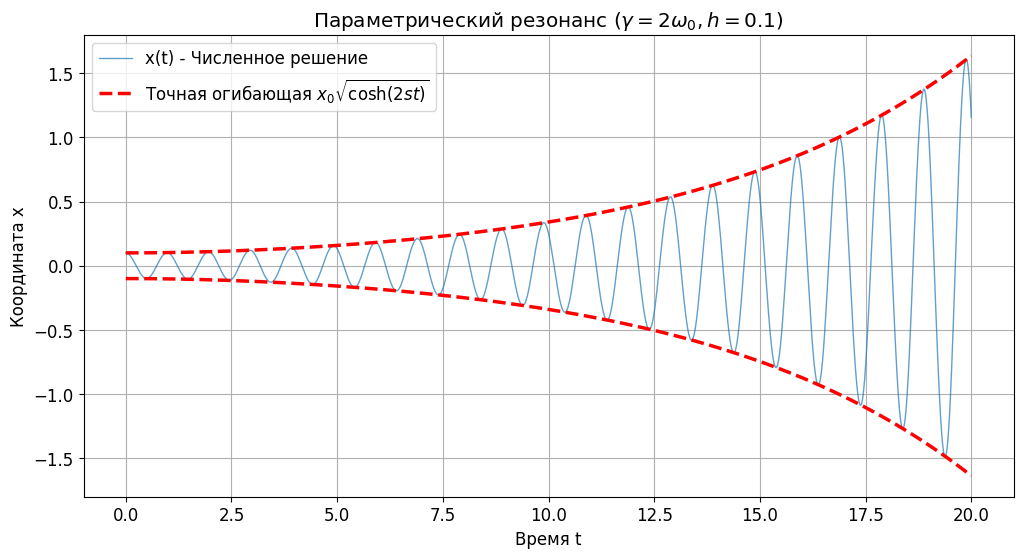

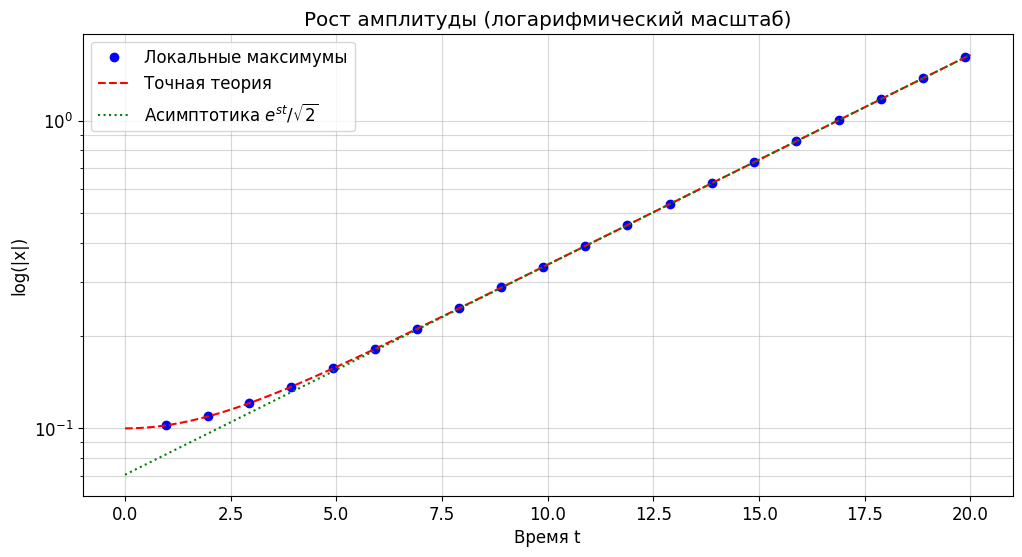

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Настройка графиков
%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

def mathieu_equation(t, y, omega0, h, gamma):
    """
    Уравнение Матье: x'' + omega0^2 * (1 + h * cos(gamma * t)) * x = 0
    """
    x, v = y
    dxdt = v
    dvdt = -omega0**2 * (1 + h * np.cos(gamma * t)) * x
    return [dxdt, dvdt]

# Параметры
omega0 = 2 * np.pi * 1.0
h = 0.1                  # Глубина модуляции
gamma = 2 * omega0       # Точный резонанс
t_max = 20.0             # Увеличим время
t_eval = np.linspace(0, t_max, 4000)

# Начальные условия
x0 = 0.1
v0 = 0.0
initial_state = [x0, v0]

# Численное решение
sol = solve_ivp(mathieu_equation, [0, t_max], initial_state, t_eval=t_eval, args=(omega0, h, gamma), rtol=1e-9, atol=1e-9)
x = sol.y[0]
t = sol.t

# Теоретическая огибающая
# Инкремент s = omega0 * h / 4
s = omega0 * h / 4

# Точное решение для огибающей при x(0)=x0, v(0)=0:
# A(t) = x0 * sqrt(cosh(2*s*t))
envelope_exact = x0 * np.sqrt(np.cosh(2 * s * t))

# Асимптотика: A(t) ~ (x0 / sqrt(2)) * exp(s*t)
envelope_asymp = (x0 / np.sqrt(2)) * np.exp(s * t)

# Визуализация
plt.figure(figsize=(12, 6))
plt.plot(t, x, label='x(t) - Численное решение', alpha=0.7, linewidth=1)
plt.plot(t, envelope_exact, 'r--', label='Точная огибающая $x_0 \sqrt{\cosh(2st)}$', linewidth=2.5)
plt.plot(t, -envelope_exact, 'r--', linewidth=2.5)

plt.title(f'Параметрический резонанс ($\gamma = 2\omega_0, h={h}$)')
plt.xlabel('Время t')
plt.ylabel('Координата x')
plt.legend(loc='upper left')
plt.grid(True)
plt.show()

# Проверка экспоненциального роста в логарифмическом масштабе
plt.figure(figsize=(12, 6))
# Берем абсолютные значения пиков
peaks_idx = np.where((x[1:-1] > x[:-2]) & (x[1:-1] > x[2:]))[0] + 1
# Фильтруем только положительные пики
peaks_idx = peaks_idx[x[peaks_idx] > 0]

plt.semilogy(t[peaks_idx], x[peaks_idx], 'bo', label='Локальные максимумы')
plt.semilogy(t, envelope_exact, 'r--', label='Точная теория')
plt.semilogy(t, envelope_asymp, 'g:', label='Асимптотика $e^{st}/\sqrt{2}$')

plt.title('Рост амплитуды (логарифмический масштаб)')
plt.xlabel('Время t')
plt.ylabel('log(|x|)')
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.show()